# 01. EDA — 이 데이터는 무엇을 담고 있고, 무엇이 없는가

> **「만약의 감독」 분석 노트북 1/9장** · 설계 정본: [노트북_서사_v1_0.md](../docs/planning/ml/version1.0/노트북_서사_v1_0.md)

## 이 장의 질문

1. 학습 데이터(`jfjelstul/worldcup`, CC BY-SA 4.0)는 실제로 무엇을 담고 있는가 — 기간·규모·품질?
2. 승/무/패의 **기저율**은 얼마이고, 시대에 따라 변했는가?
3. 득점은 정말 **포아송 분포**로 근사되는가? (07장 스코어 생성 모델의 전제 검증)
4. 개최국 효과는 데이터에서 관측되는가? (피처 후보의 근거)
5. **전술 성향 컬럼이 정말 없는가?** — ADR-008(슬라이더 = 조정 계층)의 사실 근거를 데이터로 재현

## 규약

- **시드 42 고정** · 각 장 서두 "이 장의 질문" / 말미 "이 장의 답" (노트북_서사 §1)
- **Decision Box(DB-n)**: 분석 중 설계 결정을 흐름 안에 기록 — 설계 문서의 `[설계 결정]` 태그와 상호 참조
- **실명 마스킹(NB-R1)**: 선수명 계열 컬럼은 로드 직후 제거 — 이 노트북은 공개 문서이므로
  마스킹 셀 이후 어떤 셀도 선수 실명에 접근할 수 없다. 국가·팀명은 허용(P7)
- 데이터 라이선스: 산출물은 CC BY-SA 4.0 분리 고지 대상 (P10, `DATA-LICENSE.md` 예정)

In [1]:
# 환경·시드 고정 (재현 규약 — 노트북_서사 §5)
import sys, platform, random, hashlib, json, io, urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# 한글 폰트 — 디자인 시스템 폰트(Pretendard, 시스템 설치본) 우선
matplotlib.rcParams["font.family"] = ["Pretendard", "Malgun Gothic", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "raw"
FIGURES = ROOT / "notebooks" / "figures"
DATA_RAW.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print(f"Python {sys.version.split()[0]} on {platform.system()}")
print(f"pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}")
print(f"SEED = {SEED} | ROOT = {ROOT.name}")

Python 3.12.13 on Windows
pandas 3.0.3 | numpy 1.26.4 | matplotlib 3.10.9
SEED = 42 | ROOT = ml-design-v1-planning-85d519


## 1-1. 수집 — 단일 출처 + 로컬 캐시

### Decision Box DB-01 — 수집 경로

| 항목 | 결정 | 근거 |
|---|---|---|
| 출처 | `jfjelstul/worldcup` GitHub raw (master/data-csv) **단일 출처** | P10 채택 1차 소스 — 재업로드본 사용 금지(P10의 StatsBomb 교훈) |
| 캐시 | `data/raw/`에 저장, 존재 시 재다운로드 생략 | 재현성 + 원 서버 부하 최소화 |
| 커밋 | **원본 CSV는 커밋하지 않는다** (`data/`는 .gitignore) | 선수 실명 포함 — ML-R3 "커밋 산출물 실명 0건" |
| 범위 | 이 장은 matches·team_appearances·tournaments·goals 4종만 | 팀 수준 분석에 충분 — 피처_정의서 §2의 원천 테이블 |

In [2]:
BASE = "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv/"
TABLES = ["matches", "team_appearances", "tournaments", "goals"]

def fetch(name: str) -> Path:
    """CSV 1종 다운로드(캐시 우선). 반환: 로컬 경로"""
    dest = DATA_RAW / f"{name}.csv"
    if dest.exists() and dest.stat().st_size > 0:
        print(f"  캐시 사용: {name}.csv ({dest.stat().st_size:,} bytes)")
        return dest
    url = BASE + f"{name}.csv"
    with urllib.request.urlopen(url, timeout=60) as r:
        dest.write_bytes(r.read())
    print(f"  다운로드: {name}.csv ({dest.stat().st_size:,} bytes)")
    return dest

paths = {t: fetch(t) for t in TABLES}

  다운로드: matches.csv (298,930 bytes)


  다운로드: team_appearances.csv (557,506 bytes)


  다운로드: tournaments.csv (3,287 bytes)


  다운로드: goals.csv (734,494 bytes)


## 1-2. 파일럿 검증 — 전량 분석 전, 소표본으로 스키마부터

(3조 노트북 1-3 패턴: 파일럿 → 전체. 스키마가 설계 문서의 가정과 다르면 여기서 멈춘다)

In [3]:
matches = pd.read_csv(paths["matches"])
team_apps = pd.read_csv(paths["team_appearances"])
tournaments = pd.read_csv(paths["tournaments"])

# 파일럿: 팀 수준 3개 테이블 — 스키마·타입·무작위 3행 (선수명 없음 → 표시 안전)
for name, df in [("matches", matches), ("team_appearances", team_apps), ("tournaments", tournaments)]:
    print(f"── {name}: {df.shape[0]:,}행 × {df.shape[1]}열")
    print(f"   컬럼: {list(df.columns)[:12]}{' …' if df.shape[1] > 12 else ''}")

# 설계 가정 검증: ML_설계 §3.1에서 gh api로 확인한 스키마와 일치하는가
assert {"match_id", "extra_time", "penalty_shootout", "home_team_score", "away_team_score"} <= set(matches.columns)
assert {"team_name", "goals_for", "goals_against", "match_date"} <= set(team_apps.columns)
assert {"tournament_id", "year", "host_country"} <= set(tournaments.columns)
print("\n파일럿 통과 — 설계 문서(ML_설계 §3.1)의 스키마 가정과 일치")

── matches: 1,248행 × 37열
   컬럼: ['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name', 'stage_name', 'group_name', 'group_stage', 'knockout_stage', 'replayed', 'replay', 'match_date'] …
── team_appearances: 2,496행 × 36열
   컬럼: ['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name', 'stage_name', 'group_name', 'group_stage', 'knockout_stage', 'replayed', 'replay', 'match_date'] …
── tournaments: 30행 × 18열
   컬럼: ['key_id', 'tournament_id', 'tournament_name', 'year', 'start_date', 'end_date', 'host_country', 'winner', 'host_won', 'count_teams', 'group_stage', 'second_group_stage'] …

파일럿 통과 — 설계 문서(ML_설계 §3.1)의 스키마 가정과 일치


## 1-3. 실명 마스킹 셀 — NB-R1 (이 노트북의 경계선)

`goals`에는 득점자 실명 컬럼이 있다. **이 셀에서 즉시 제거**하고 원본 변수를 삭제한다.
이후 어떤 셀도 실명에 접근할 수 없다 — "조심"이 아니라 **변수 부재**로 보장한다
([ML_설계 §3.3](../docs/planning/ml/version1.0/ML_설계_v1_0.md) 구획 ③, ADR-005와 동일 철학).
`player_id`(무의미 코드)는 유지한다 — 분 단위 집계에 필요하며 실명이 아니다.

In [4]:
_goals_raw = pd.read_csv(paths["goals"])
_name_cols = [c for c in _goals_raw.columns
              if any(k in c.lower() for k in ("given_name", "family_name", "player_name", "full_name"))]
goals = _goals_raw.drop(columns=_name_cols)
del _goals_raw  # 원본 변수 삭제 — 이후 셀에서 실명 접근 불가

print(f"제거된 실명 컬럼: {_name_cols}")
print(f"유지 컬럼: {list(goals.columns)}")
# 게이트: 남은 컬럼에 실명 계열이 없어야 한다
assert not any(any(k in c.lower() for k in ("given_name", "family_name", "player_name")) for c in goals.columns)
print("마스킹 게이트 통과 — goals에 실명 컬럼 0개")

제거된 실명 컬럼: ['family_name', 'given_name']
유지 컬럼: ['key_id', 'goal_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name', 'match_date', 'stage_name', 'group_name', 'team_id', 'team_name', 'team_code', 'home_team', 'away_team', 'player_id', 'shirt_number', 'player_team_id', 'player_team_name', 'player_team_code', 'minute_label', 'minute_regulation', 'minute_stoppage', 'match_period', 'own_goal', 'penalty']
마스킹 게이트 통과 — goals에 실명 컬럼 0개


## 2. 데이터 개요 — 기간·규모·품질 진단

In [5]:
# 남자/여자 대회 분리 (ADR-007: 주 학습은 남자 대회, 여자는 증강 실험)
tournaments["is_mens"] = tournaments["tournament_name"].str.contains("Men")
mens_ids = set(tournaments.loc[tournaments["is_mens"], "tournament_id"])

m_matches = matches[matches["tournament_id"].isin(mens_ids)].copy()
m_apps = team_apps[team_apps["tournament_id"].isin(mens_ids)].copy()

summary = pd.DataFrame({
    "행 수": [len(matches), len(m_matches), len(team_apps), len(goals), len(tournaments)],
    "설명": ["경기 전체(남+여)", "남자 대회 경기", "팀-경기 전체", "득점 이벤트(마스킹됨)", "대회"],
}, index=["matches", "matches(남)", "team_appearances", "goals", "tournaments"])
print(summary)

mens_t = tournaments[tournaments["is_mens"]]
print(f"\n남자 대회: {len(mens_t)}개 ({mens_t['year'].min()}~{mens_t['year'].max()}) — 설계 가정(22개 대회) 검증")
assert len(mens_t) == 22, "ADR-007 전제(남자 22개 대회) 불일치"

# 품질: 결측·중복
print(f"\nmatches 결측 상위: ")
na = m_matches.isna().sum()
print(na[na > 0].sort_values(ascending=False).head(5) if (na > 0).any() else "  핵심 컬럼 결측 없음")
print(f"match_id 중복: {m_matches['match_id'].duplicated().sum()}건")

                   행 수            설명
matches           1248    경기 전체(남+여)
matches(남)         964      남자 대회 경기
team_appearances  2496       팀-경기 전체
goals             3637  득점 이벤트(마스킹됨)
tournaments         30            대회

남자 대회: 22개 (1930~2022) — 설계 가정(22개 대회) 검증

matches 결측 상위: 
  핵심 컬럼 결측 없음
match_id 중복: 0건


## 3. 라벨 기초 — 승/무/패 기저율

### Decision Box DB-02 — 90분 기준 라벨 재구성

[피처_정의서 §2](../docs/planning/ml/version1.0/피처_정의서_v1_0.md)의 `[설계 결정]`을 구현한다:
**라벨 = 정규 90분 기준 승/무/패.** `extra_time` 또는 `penalty_shootout`이 참인 경기는 90분
시점에 동점이었으므로 무승부로 계상한다. 서비스의 예측 대상(조별리그 컨텍스트)에서 무승부는
유효한 결과이기 때문이다. 아래에서 재구성 라벨과 원본 `result`의 차이(= 연장/승부차기 경기 수)를
확인해 변환이 의도대로인지 검증한다.

In [6]:
def label_90min(row) -> str:
    """90분 기준 결과 — 연장·승부차기는 90분 무승부"""
    if row["extra_time"] == 1 or row["penalty_shootout"] == 1:
        return "draw"
    if row["home_team_score"] > row["away_team_score"]:
        return "home_win"
    if row["home_team_score"] < row["away_team_score"]:
        return "away_win"
    return "draw"

m_matches["label90"] = m_matches.apply(label_90min, axis=1)
n_et = int(((m_matches["extra_time"] == 1) | (m_matches["penalty_shootout"] == 1)).sum())
print(f"연장/승부차기 경기(→ 90분 무승부 계상): {n_et}건 / {len(m_matches)}경기")

base = m_matches["label90"].value_counts(normalize=True).rename("비율")
print("\n승/무/패 기저율 (홈 팀 기준, 90분):")
print((base * 100).round(1).astype(str) + "%")

연장/승부차기 경기(→ 90분 무승부 계상): 73건 / 964경기

승/무/패 기저율 (홈 팀 기준, 90분):
label90
home_win    52.2%
draw        25.5%
away_win    22.3%
Name: 비율, dtype: str


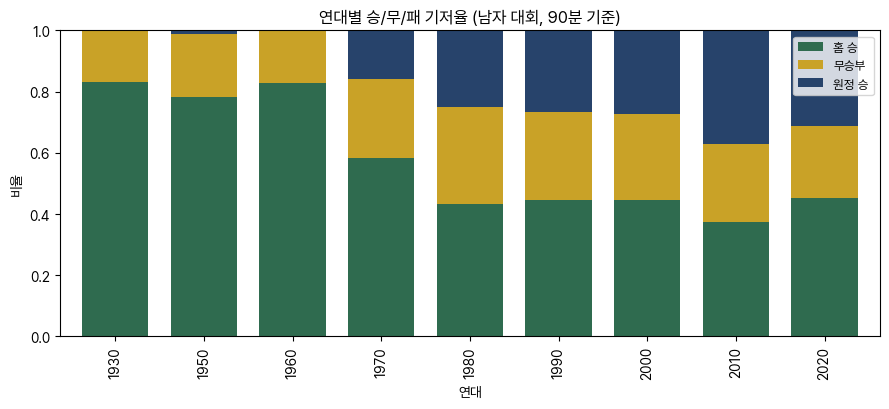

1990년대 이후 무승부 비율 평균: 26.4% — 폴백 산식(ML_설계 §6.3)의 d̂ 상수 후보


In [7]:
# 연대별 기저율 추이 — 무승부 비율의 시대 변화
m_matches["year"] = m_matches["tournament_id"].map(tournaments.set_index("tournament_id")["year"])
m_matches["era"] = (m_matches["year"] // 10 * 10).astype(int)

era_rates = (m_matches.groupby("era")["label90"]
             .value_counts(normalize=True).unstack().fillna(0))
fig, ax = plt.subplots(figsize=(9, 4.2))
era_rates[["home_win", "draw", "away_win"]].plot(
    kind="bar", stacked=True, ax=ax,
    color=["#2f6b4f", "#c9a227", "#27436b"], width=0.75)
ax.set_title("연대별 승/무/패 기저율 (남자 대회, 90분 기준)")
ax.set_xlabel("연대"); ax.set_ylabel("비율")
ax.legend(["홈 승", "무승부", "원정 승"], loc="upper right", fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES / "01_baserate_by_era.png", dpi=150)
plt.show()

draw_recent = era_rates.loc[era_rates.index >= 1990, "draw"].mean()
print(f"1990년대 이후 무승부 비율 평균: {draw_recent:.1%} — 폴백 산식(ML_설계 §6.3)의 d̂ 상수 후보")

## 4. 득점 분포 — 포아송 근사는 성립하는가

07장 스코어 생성 모델(bivpois λ + Dixon-Coles τ, ADR-006)은 "팀당 득점이 포아송으로
근사된다"를 전제한다. 전제를 **먼저 데이터로 확인**한다 — 히스토그램과 λ=표본평균 포아송
pmf를 겹쳐 보고, 저점수 구간의 이탈(τ 보정이 필요한 이유)을 관찰한다.

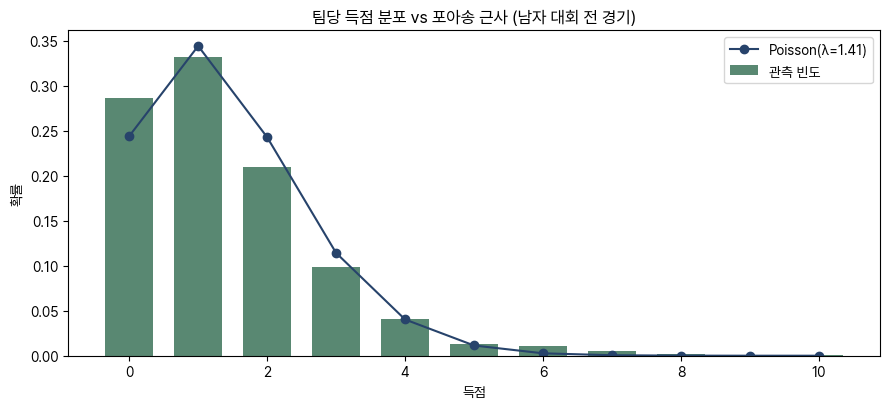

저점수(0~2골) 구간 관측 vs 이론:
       관측     포아송  차이(관측-이론)
0  0.2863  0.2440     0.0424
1  0.3314  0.3442    -0.0127
2  0.2095  0.2428    -0.0332

→ 근사는 대체로 성립하되 저점수 구간에 이탈이 있다 — DC τ 보정(ADR-006)의 데이터 근거


In [8]:
gf = m_apps["goals_for"].astype(int)
lam = gf.mean()
ks = np.arange(0, gf.max() + 1)
obs = gf.value_counts(normalize=True).reindex(ks, fill_value=0)
pois = stats.poisson.pmf(ks, lam)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(ks, obs, width=0.7, color="#2f6b4f", alpha=0.8, label="관측 빈도")
ax.plot(ks, pois, "o-", color="#27436b", label=f"Poisson(λ={lam:.2f})")
ax.set_title("팀당 득점 분포 vs 포아송 근사 (남자 대회 전 경기)")
ax.set_xlabel("득점"); ax.set_ylabel("확률")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES / "01_goals_poisson.png", dpi=150)
plt.show()

# 저점수 이탈 정량 — Dixon-Coles τ 보정의 근거
dev = pd.DataFrame({"관측": obs.iloc[:3].values, "포아송": pois[:3]}, index=[0, 1, 2])
dev["차이(관측-이론)"] = dev["관측"] - dev["포아송"]
print("저점수(0~2골) 구간 관측 vs 이론:")
print(dev.round(4))
print("\n→ 근사는 대체로 성립하되 저점수 구간에 이탈이 있다 — DC τ 보정(ADR-006)의 데이터 근거")

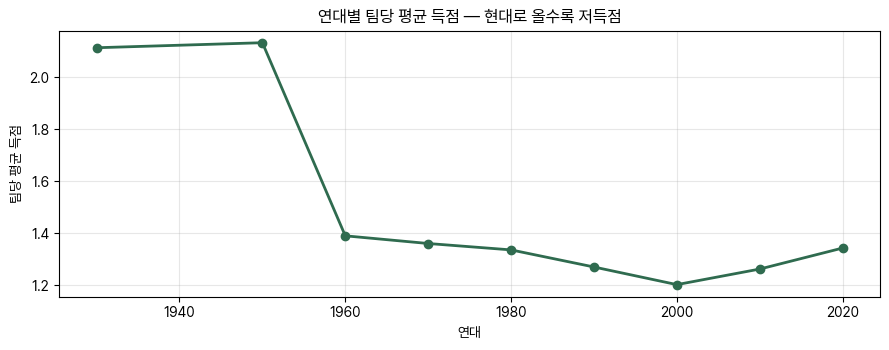

era
1930    2.11
1950    2.13
1960    1.39
1970    1.36
1980    1.34
1990    1.27
2000    1.20
2010    1.26
2020    1.34
Name: goals_for, dtype: float64

→ 초기 대회(1930~50년대)의 고득점은 현대와 분포가 다르다 — 시간 감쇠·시대 피처를 두지 않는 대신, Elo가 시대 내 상대 강도를 흡수하는지 02장에서 확인


In [9]:
# 시대별 평균 득점 추이 — 저득점화 경향 (시계열 감각)
era_goals = m_apps.merge(
    tournaments[["tournament_id", "year"]], on="tournament_id")
era_goals["era"] = (era_goals["year"] // 10 * 10).astype(int)
trend = era_goals.groupby("era")["goals_for"].mean()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(trend.index, trend.values, "o-", color="#2f6b4f", linewidth=2)
ax.set_title("연대별 팀당 평균 득점 — 현대로 올수록 저득점")
ax.set_xlabel("연대"); ax.set_ylabel("팀당 평균 득점")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / "01_goals_era_trend.png", dpi=150)
plt.show()
print(trend.round(2))
print("\n→ 초기 대회(1930~50년대)의 고득점은 현대와 분포가 다르다 — 시간 감쇠·시대 피처를"
      " 두지 않는 대신, Elo가 시대 내 상대 강도를 흡수하는지 02장에서 확인")

## 5. 개최국 효과 — host 피처의 근거

월드컵은 대부분 중립 경기지만 개최국만은 예외다. 피처_정의서 §2의 `host` 피처가 실제로
신호를 갖는지 기초 통계로 확인한다. (공동 개최 대회는 문자열 포함 매칭으로 처리)

In [10]:
m_apps2 = m_apps.merge(tournaments[["tournament_id", "host_country"]], on="tournament_id")
m_apps2["is_host"] = m_apps2.apply(
    lambda r: str(r["team_name"]) in str(r["host_country"]), axis=1)

host_stats = m_apps2.groupby("is_host").agg(
    경기수=("win", "size"), 승률=("win", "mean"),
    평균득점=("goals_for", "mean"), 평균실점=("goals_against", "mean")).round(3)
host_stats.index = ["비개최국", "개최국"]
print(host_stats)

diff = host_stats.loc["개최국", "승률"] - host_stats.loc["비개최국", "승률"]
print(f"\n개최국 승률 우위: +{diff:.1%}p — host 피처 채택의 데이터 근거 (피처_정의서 §2)")

       경기수     승률   평균득점   평균실점
비개최국  1814  0.391  1.381  1.437
개최국    114  0.658  1.877  1.000

개최국 승률 우위: +26.7%p — host 피처 채택의 데이터 근거 (피처_정의서 §2)


## 6. 전술 컬럼 부재 확인 — ADR-008의 사실 근거를 데이터로 재현

[ADR-008](../docs/planning/decisions/ADR-008-슬라이더매핑.md)은 "학습 데이터에 전술 성향
컬럼이 존재하지 않는다"를 근거로 슬라이더를 학습 피처가 아닌 **입력 조정 계층**으로 확정했다.
그 사실 확인을 노트북 안에서 재현한다 — 데이터셋 27개 테이블 전체의 헤더를 스캔해 전술
키워드(formation·tactic·press·tempo·style·system)를 검색한다. (헤더만 소량 요청, 결과 캐시)

In [11]:
ALL_TABLES = [
    "award_winners", "awards", "bookings", "confederations", "goals", "group_standings",
    "groups", "host_countries", "manager_appearances", "manager_appointments", "managers",
    "matches", "penalty_kicks", "player_appearances", "players", "qualified_teams",
    "referee_appearances", "referee_appointments", "referees", "squads", "stadiums",
    "substitutions", "team_appearances", "teams", "tournament_stages",
    "tournament_standings", "tournaments"]
KEYWORDS = ("formation", "tactic", "press", "tempo", "style", "system")

cache = DATA_RAW / "_headers.json"
if cache.exists():
    headers = json.loads(cache.read_text(encoding="utf-8"))
    print("헤더 캐시 사용")
else:
    headers = {}
    for t in ALL_TABLES:
        req = urllib.request.Request(BASE + f"{t}.csv", headers={"Range": "bytes=0-4095"})
        try:
            with urllib.request.urlopen(req, timeout=30) as r:
                first = r.read().decode("utf-8", errors="replace").splitlines()[0]
            headers[t] = first.split(",")
        except Exception as e:  # 네트워크 실패는 기록만 (비치명)
            headers[t] = [f"<fetch 실패: {e}>"]
    cache.write_text(json.dumps(headers, ensure_ascii=False, indent=1), encoding="utf-8")
    print(f"27개 테이블 헤더 수집·캐시 완료")

hits = {t: [c for c in cols if any(k in c.lower() for k in KEYWORDS)]
        for t, cols in headers.items()}
found = {t: h for t, h in hits.items() if h}
total_cols = sum(len(c) for c in headers.values())
print(f"\n스캔: 테이블 {len(headers)}개 · 컬럼 {total_cols}개 · 전술 키워드 매치: {sum(len(h) for h in found.values())}건")
print(f"매치 상세: {found if found else '없음 — 전술 성향 컬럼 부재 확인'}")
assert not found, "전술 컬럼 발견 — ADR-008 재검토 필요"
print("\n→ ADR-008의 전제가 데이터 전수 스캔으로 재확인됨: 슬라이더는 조정 계층이 유일한 경로")

27개 테이블 헤더 수집·캐시 완료

스캔: 테이블 27개 · 컬럼 410개 · 전술 키워드 매치: 0건
매치 상세: 없음 — 전술 성향 컬럼 부재 확인

→ ADR-008의 전제가 데이터 전수 스캔으로 재확인됨: 슬라이더는 조정 계층이 유일한 경로


## 7. 이 장의 답

| 질문 | 답 | 후속 |
|---|---|---|
| 데이터 실체 | 남자 대회 22개(1930~2022) 정상 적재 · 핵심 컬럼 결측 없음 · match_id 중복 0 | 02장 피처로 진행 |
| 기저율 | 위 3절 실측 — 90분 무승부 비율(1990~)이 폴백 산식 d̂ 상수의 후보값 | ML_설계 §6.3 d̂ 확정 재료 |
| 포아송 근사 | 대체로 성립, **저점수 구간 이탈 관측** — DC τ 보정의 데이터 근거 확보 | 07장 스코어 모델 |
| 개최국 효과 | 개최국 승률 우위 실측 — host 피처 근거 | 02장 피처 채택 |
| 전술 컬럼 | **27개 테이블 전수 스캔 매치 0건** — ADR-008 전제 재확인 | 조정 계층 확정 유지 |

**기획서 반영 후보** (조판 블록 인계):
- 9·10절: 기저율·득점 분포 실측 그림(`01_goals_poisson.png`) — "포아송 전제를 데이터로 확인했다"
- 10절 한계 고지: 저점수 이탈 → τ 보정 필요성의 실측 근거
- 16절 부록: 본 노트북 산출 수치의 출처를 "자체 분석(01장)"으로 등재

**02장 인계 조건**: `data/raw/` 4테이블 적재 완료 · 남자 22개 대회 검증 통과 · 마스킹 게이트 통과